# Polymarket Trading Performance Analysis

This notebook analyzes closed trading positions from Polymarket and generates professional performance metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import glob
import os
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Configuration - Enter Your Wallet Address

**Enter wallet address to analyze (or leave empty for latest data):**

In [2]:
# Enter wallet address here (or leave empty to use latest data files)
WALLET_ADDRESS = ""  # Example: "0x670aB9580B4e21735dD4c30fEF45bb9f465100C9"

# Find data directory
data_dir = '../data' if os.path.exists('../data') else 'data' if os.path.exists('data') else '.'

# Find CSV files - only need closed positions
if WALLET_ADDRESS:
    # Match specific wallet (case-insensitive) - try exact match first, then prefix
    all_files = glob.glob(f'{data_dir}/polymarket_closed_positions_*.csv')
    # Try exact match first (full wallet address)
    positions_files = [f for f in all_files if WALLET_ADDRESS.lower() in os.path.basename(f).lower()]
    # If no exact match, try prefix match (first 10 chars for backwards compatibility)
    if not positions_files:
        wallet_short = WALLET_ADDRESS[:10]
        positions_files = [f for f in all_files if wallet_short.lower() in os.path.basename(f).lower()]
    print(f"Looking for wallet: {WALLET_ADDRESS}...")
else:
    # Use latest files
    positions_files = glob.glob(f'{data_dir}/polymarket_closed_positions_*.csv')
    print("Looking for latest data files...")

if not positions_files:
    print("\n" + "="*80)
    print("ERROR: No closed positions data found!")
    print("="*80)
    if WALLET_ADDRESS:
        print(f"\nNo data found for wallet: {WALLET_ADDRESS}")
    print("\nPlease run the data fetcher first:")
    print("  cd scripts")
    print("  python3 polymarket_api_fetcher.py <wallet_address>")
    print("\nThis will generate the required CSV file in the data/ directory")
    raise FileNotFoundError("Closed positions data not found")

# Use most recent file
positions_file = sorted(positions_files)[-1]

# Extract wallet address from filename
wallet_from_file = positions_file.split('_')[-1].replace('.csv', '')

print(f"\n{'='*80}")
print(f"Loading data for wallet: {wallet_from_file}")
print(f"  Positions: {positions_file}")
print(f"{'='*80}\n")

Looking for latest data files...

Loading data for wallet: 0xeebde7a0
  Positions: ../data/polymarket_closed_positions_0xeebde7a0.csv



## 1. Load Data

In [3]:
# Load closed positions
positions = pd.read_csv(positions_file)

# Convert timestamps
positions['Timestamp'] = pd.to_datetime(positions['Timestamp'])

print(f"Loaded {len(positions)} closed positions")

# Calculate total trades from positions data (more reliable)
total_trades = positions['Trades'].sum() if 'Trades' in positions.columns else 0
if total_trades > 0:
    print(f"Total trades across all positions: {int(total_trades)}")
    
print(f"\nData date range: {positions['Timestamp'].min()} to {positions['Timestamp'].max()}")

Loaded 6000 closed positions
Total trades across all positions: 4664

Data date range: 2026-04-27 18:44:44 to 2026-05-03 22:55:26


## 2. Overall Performance Metrics

In [4]:
# Calculate key metrics
total_pnl = positions['Realized PnL'].sum()
num_positions = len(positions)
winning_positions = positions[positions['Realized PnL'] > 0]
losing_positions = positions[positions['Realized PnL'] < 0]
breakeven_positions = positions[positions['Realized PnL'] == 0]

win_rate = len(winning_positions) / num_positions * 100
avg_win = winning_positions['Realized PnL'].mean() if len(winning_positions) > 0 else 0
avg_loss = losing_positions['Realized PnL'].mean() if len(losing_positions) > 0 else 0
best_trade = positions['Realized PnL'].max()
worst_trade = positions['Realized PnL'].min()
total_capital_deployed = trades['Size'].sum() * trades['Price'].sum() / int(total_trades) if total_trades > 0 else 0  # Approximate

# Risk/Reward ratio
risk_reward_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else 0

# Profit factor
total_wins = winning_positions['Realized PnL'].sum()
total_losses = abs(losing_positions['Realized PnL'].sum())
profit_factor = total_wins / total_losses if total_losses > 0 else 0

# Create summary DataFrame
summary_metrics = pd.DataFrame({
    'Metric': [
        'Total Realized PnL',
        'Total Positions',
        'Winning Positions',
        'Losing Positions',
        'Breakeven Positions',
        'Win Rate',
        'Average Win',
        'Average Loss',
        'Best Trade',
        'Worst Trade',
        'Risk/Reward Ratio',
        'Profit Factor',
        'Total Trades Executed'
    ],
    'Value': [
        f"${total_pnl:.2f}",
        num_positions,
        len(winning_positions),
        len(losing_positions),
        len(breakeven_positions),
        f"{win_rate:.2f}%",
        f"${avg_win:.2f}",
        f"${avg_loss:.2f}",
        f"${best_trade:.2f}",
        f"${worst_trade:.2f}",
        f"{risk_reward_ratio:.2f}",
        f"{profit_factor:.2f}",
        int(total_trades) if total_trades > 0 else 0
    ]
})

print("\n" + "="*60)
print("PERFORMANCE SUMMARY")
print("="*60)
print(summary_metrics.to_string(index=False))
print("="*60)

NameError: name 'trades' is not defined

## 3. Top 10 Best & Worst Trades

In [19]:
# Top 10 winners
top_winners = positions.nlargest(10, 'Realized PnL')[[
    'Market Title', 'Outcome', 'Realized PnL', 'Avg Price', 'Total Bought', 'Timestamp'
]].copy()
top_winners['Timestamp'] = top_winners['Timestamp'].dt.strftime('%Y-%m-%d %H:%M')

print("\nTOP 10 WINNING TRADES")
print("="*120)
print(top_winners.to_string(index=False))

# Top 10 losers
top_losers = positions.nsmallest(10, 'Realized PnL')[[
    'Market Title', 'Outcome', 'Realized PnL', 'Avg Price', 'Total Bought', 'Timestamp'
]].copy()
top_losers['Timestamp'] = top_losers['Timestamp'].dt.strftime('%Y-%m-%d %H:%M')

print("\n\nTOP 10 LOSING TRADES")
print("="*120)
print(top_losers.to_string(index=False))


TOP 10 WINNING TRADES
                                     Market Title Outcome  Realized PnL  Avg Price  Total Bought        Timestamp
Bitcoin Up or Down - April 29, 10:20AM-10:25AM ET      Up   2098.264323   0.245106   2779.548285 2026-04-29 17:24
Bitcoin Up or Down - April 29, 10:20AM-10:25AM ET      Up   2098.264323   0.245106   2779.548285 2026-04-29 17:24
  Bitcoin Up or Down - April 30, 4:45AM-4:50AM ET      Up   2019.589655   0.177802   2456.330051 2026-04-30 11:50
  Bitcoin Up or Down - April 30, 4:45AM-4:50AM ET      Up   2019.589655   0.177802   2456.330051 2026-04-30 11:50
  Bitcoin Up or Down - April 29, 3:00PM-3:15PM ET      Up   1775.113956   0.357677   2763.584607 2026-04-29 22:14
  Bitcoin Up or Down - April 29, 4:00PM-4:15PM ET    Down   1560.397588   0.324918   2311.419335 2026-04-29 23:14
   Bitcoin Up or Down - May 1, 12:35PM-12:40PM ET      Up   1556.010728   0.278933   2157.928082 2026-05-01 19:40
   Bitcoin Up or Down - May 1, 11:05AM-11:10AM ET      Up   1509.

## 4. All Closed Positions (Exchange-Style List)

In [5]:
# Create exchange-style closed positions table
closed_positions_table = positions[[
    'Timestamp', 'Market Title', 'Outcome', 'Avg Price', 'Total Bought', 
    'Current Price', 'Realized PnL'
]].copy()

# Sort by timestamp descending (most recent first)
closed_positions_table = closed_positions_table.sort_values('Timestamp', ascending=False)

# Format timestamp
closed_positions_table['Timestamp'] = closed_positions_table['Timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')

# Rename columns to match exchange style
closed_positions_table.columns = [
    'Close Time', 'Market', 'Side', 'Entry Price', 'Size', 'Exit Price', 'PnL ($)'
]

# Add ROI column
closed_positions_table['ROI (%)'] = (
    positions['Realized PnL'].values / 
    (positions['Avg Price'].values * positions['Total Bought'].values) * 100
).round(2)

# Format PnL with colors (for display)
closed_positions_table['PnL ($)'] = closed_positions_table['PnL ($)'].apply(lambda x: f"${x:.2f}")

print("\n" + "="*140)
print("ALL CLOSED POSITIONS (EXCHANGE STYLE)")
print("="*140)
print(closed_positions_table.to_string(index=False))
print("="*140)


ALL CLOSED POSITIONS (EXCHANGE STYLE)
         Close Time                                             Market Side  Entry Price         Size  Exit Price   PnL ($)  ROI (%)
2026-05-03 22:55:26       Bitcoin Up or Down - May 3, 3:50PM-3:55PM ET   Up     0.433027  2558.380381       0.270  $-417.09   -37.65
2026-05-03 22:55:18      Ethereum Up or Down - May 3, 3:50PM-3:55PM ET Down     0.233898   290.401349       0.505    $78.73   115.91
2026-05-03 22:55:18       Bitcoin Up or Down - May 3, 3:50PM-3:55PM ET Down     0.623569  1073.934606       0.730   $114.30    17.07
2026-05-03 22:53:20      Ethereum Up or Down - May 3, 3:50PM-3:55PM ET   Up     0.518817   172.923332       0.495    $-4.12    -4.59
2026-05-03 22:49:46       Bitcoin Up or Down - May 3, 3:45PM-3:50PM ET   Up     0.218479  1875.614865       0.000  $-409.78  -100.00
2026-05-03 22:49:24       Bitcoin Up or Down - May 3, 3:45PM-3:50PM ET Down     0.877402  6248.929397       1.000   $766.11    13.97
2026-05-03 22:49:00      Ether

## 5. Performance Visualizations


✓ Saved performance dashboard to performance_dashboard.png


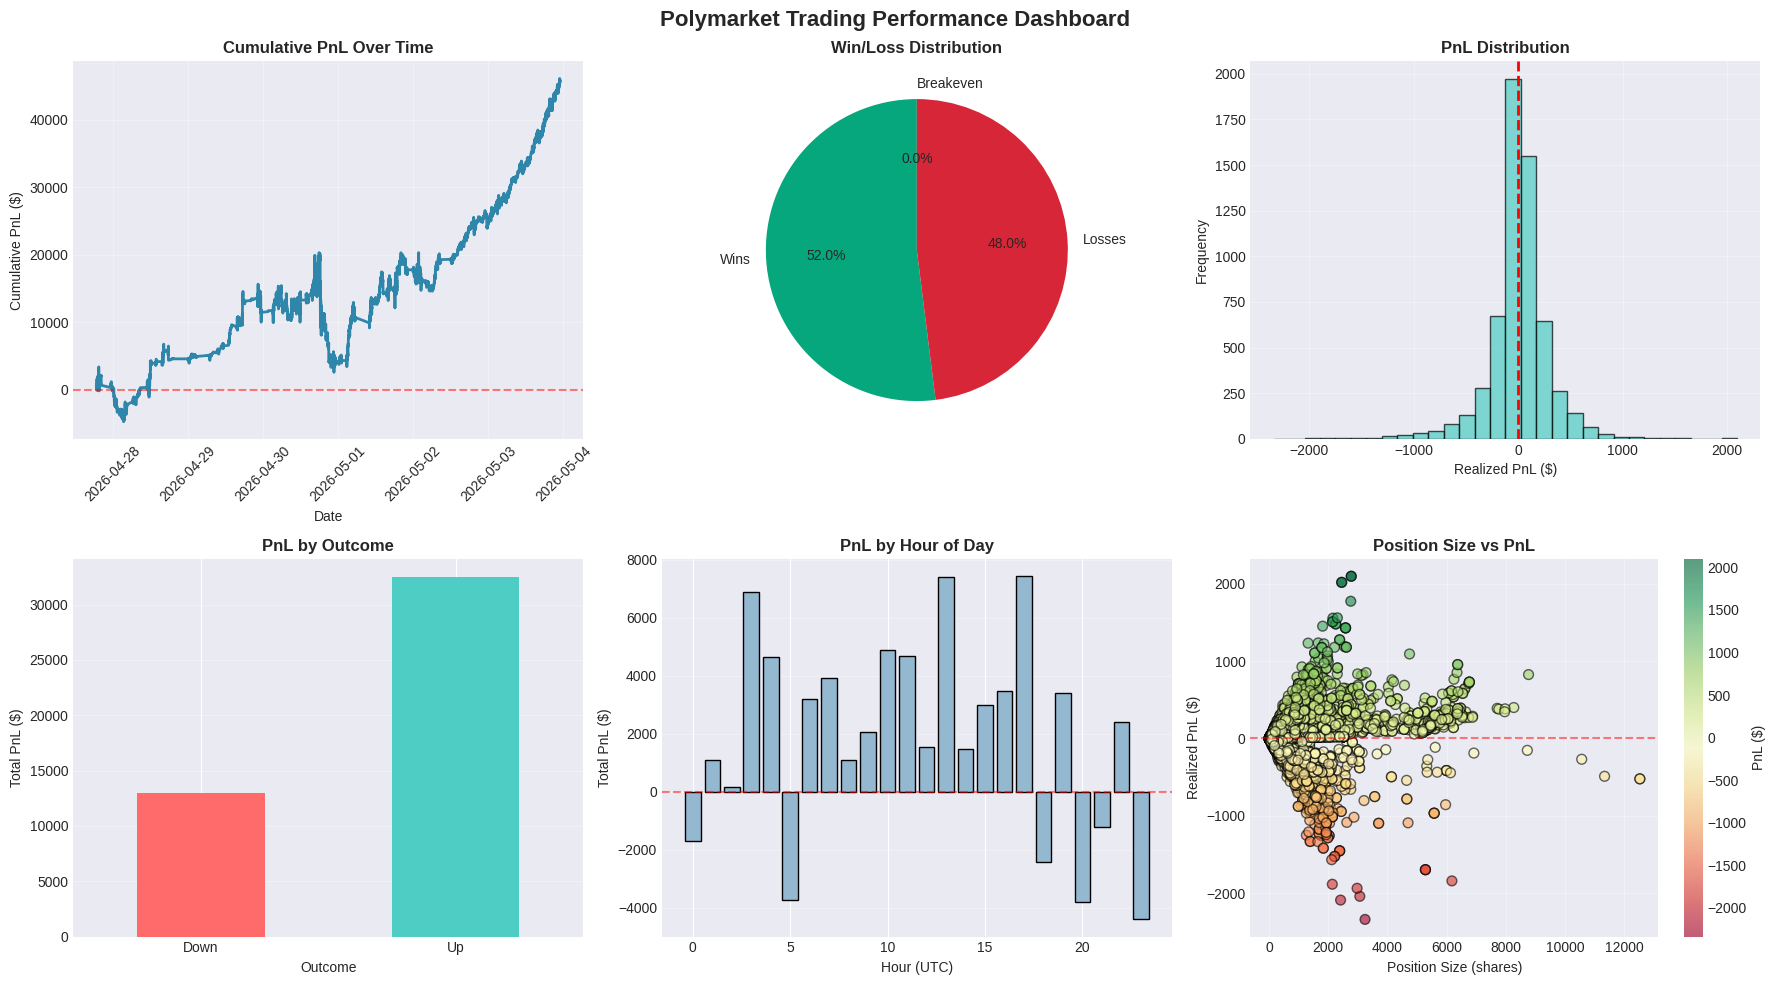

In [6]:
# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Polymarket Trading Performance Dashboard', fontsize=16, fontweight='bold')

# 1. Cumulative PnL over time
positions_sorted = positions.sort_values('Timestamp')
positions_sorted['Cumulative PnL'] = positions_sorted['Realized PnL'].cumsum()
axes[0, 0].plot(positions_sorted['Timestamp'], positions_sorted['Cumulative PnL'], 
                linewidth=2, color='#2E86AB')
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Cumulative PnL Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Cumulative PnL ($)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Win/Loss distribution
win_loss_data = [len(winning_positions), len(losing_positions), len(breakeven_positions)]
colors = ['#06A77D', '#D72638', '#FFA69E']
axes[0, 1].pie(win_loss_data, labels=['Wins', 'Losses', 'Breakeven'], 
               autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 1].set_title('Win/Loss Distribution', fontweight='bold')

# 3. PnL distribution histogram
axes[0, 2].hist(positions['Realized PnL'], bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 2].set_title('PnL Distribution', fontweight='bold')
axes[0, 2].set_xlabel('Realized PnL ($)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].grid(True, alpha=0.3)

# 4. Outcomes analysis (Up vs Down)
outcome_pnl = positions.groupby('Outcome')['Realized PnL'].sum()
outcome_pnl.plot(kind='bar', ax=axes[1, 0], color=['#FF6B6B', '#4ECDC4'])
axes[1, 0].set_title('PnL by Outcome', fontweight='bold')
axes[1, 0].set_xlabel('Outcome')
axes[1, 0].set_ylabel('Total PnL ($)')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Win/Loss by hour of day
positions_sorted['Hour'] = positions_sorted['Timestamp'].dt.hour
hourly_pnl = positions_sorted.groupby('Hour')['Realized PnL'].sum()
axes[1, 1].bar(hourly_pnl.index, hourly_pnl.values, color='#95B8D1', edgecolor='black')
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_title('PnL by Hour of Day', fontweight='bold')
axes[1, 1].set_xlabel('Hour (UTC)')
axes[1, 1].set_ylabel('Total PnL ($)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 6. Position size vs PnL scatter
scatter = axes[1, 2].scatter(positions['Total Bought'], positions['Realized PnL'], 
                             c=positions['Realized PnL'], cmap='RdYlGn', 
                             alpha=0.6, edgecolors='black', s=50)
axes[1, 2].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 2].set_title('Position Size vs PnL', fontweight='bold')
axes[1, 2].set_xlabel('Position Size (shares)')
axes[1, 2].set_ylabel('Realized PnL ($)')
axes[1, 2].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 2], label='PnL ($)')

plt.tight_layout()
plt.savefig('performance_dashboard.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved performance dashboard to performance_dashboard.png")

## 6. Export to PDF

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

# Create PDF
# Save to reports directory
reports_dir = '../reports' if os.path.exists('../reports') else 'reports'
os.makedirs(reports_dir, exist_ok=True)

pdf_filename = f'{reports_dir}/polymarket_performance_report_{wallet_from_file}_{datetime.now().strftime("%Y%m%d_%H%M%S")}.pdf'

with PdfPages(pdf_filename) as pdf:
    
    # Page 1: Summary metrics and visualizations
    fig1, axes1 = plt.subplots(2, 3, figsize=(16, 11))
    fig1.suptitle('Polymarket Trading Performance Report\nWallet: {wallet_from_file}', 
                  fontsize=14, fontweight='bold')
    
    # Recreate the visualizations for PDF
    # 1. Cumulative PnL
    axes1[0, 0].plot(positions_sorted['Timestamp'], positions_sorted['Cumulative PnL'], 
                    linewidth=2, color='#2E86AB')
    axes1[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes1[0, 0].set_title('Cumulative PnL Over Time', fontweight='bold')
    axes1[0, 0].set_ylabel('Cumulative PnL ($)')
    axes1[0, 0].grid(True, alpha=0.3)
    axes1[0, 0].tick_params(axis='x', rotation=45)
    
    # 2. Win/Loss pie chart
    axes1[0, 1].pie(win_loss_data, labels=['Wins', 'Losses', 'Breakeven'], 
                   autopct='%1.1f%%', colors=colors, startangle=90)
    axes1[0, 1].set_title('Win/Loss Distribution', fontweight='bold')
    
    # 3. PnL histogram
    axes1[0, 2].hist(positions['Realized PnL'], bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
    axes1[0, 2].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes1[0, 2].set_title('PnL Distribution', fontweight='bold')
    axes1[0, 2].set_xlabel('Realized PnL ($)')
    axes1[0, 2].set_ylabel('Frequency')
    axes1[0, 2].grid(True, alpha=0.3)
    
    # 4. Outcome analysis
    outcome_pnl.plot(kind='bar', ax=axes1[1, 0], color=['#FF6B6B', '#4ECDC4'])
    axes1[1, 0].set_title('PnL by Outcome', fontweight='bold')
    axes1[1, 0].set_xlabel('Outcome')
    axes1[1, 0].set_ylabel('Total PnL ($)')
    axes1[1, 0].tick_params(axis='x', rotation=0)
    axes1[1, 0].grid(True, alpha=0.3, axis='y')
    
    # 5. Hourly PnL
    axes1[1, 1].bar(hourly_pnl.index, hourly_pnl.values, color='#95B8D1', edgecolor='black')
    axes1[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes1[1, 1].set_title('PnL by Hour of Day', fontweight='bold')
    axes1[1, 1].set_xlabel('Hour (UTC)')
    axes1[1, 1].set_ylabel('Total PnL ($)')
    axes1[1, 1].grid(True, alpha=0.3, axis='y')
    
    # 6. Summary metrics table
    axes1[1, 2].axis('off')
    table_data = summary_metrics.values
    table = axes1[1, 2].table(cellText=table_data, colLabels=['Metric', 'Value'],
                             cellLoc='left', loc='center', 
                             colWidths=[0.6, 0.4])
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.5)
    
    # Style table header
    for i in range(2):
        table[(0, i)].set_facecolor('#2E86AB')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    plt.tight_layout()
    pdf.savefig(fig1, bbox_inches='tight')
    plt.close()
    
    # Page 2: Top Winners and Losers
    fig2 = plt.figure(figsize=(16, 11))
    fig2.suptitle('Top 10 Best & Worst Trades', fontsize=14, fontweight='bold')
    
    # Create text for winners
    ax1 = plt.subplot(2, 1, 1)
    ax1.axis('off')
    winners_table = ax1.table(
        cellText=top_winners.values,
        colLabels=top_winners.columns,
        cellLoc='left',
        loc='center',
        colWidths=[0.4, 0.1, 0.15, 0.1, 0.1, 0.15]
    )
    winners_table.auto_set_font_size(False)
    winners_table.set_fontsize(8)
    winners_table.scale(1, 2)
    
    # Style header
    for i in range(len(top_winners.columns)):
        winners_table[(0, i)].set_facecolor('#06A77D')
        winners_table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax1.set_title('Top 10 Winning Trades', fontweight='bold', pad=20)
    
    # Create text for losers
    ax2 = plt.subplot(2, 1, 2)
    ax2.axis('off')
    losers_table = ax2.table(
        cellText=top_losers.values,
        colLabels=top_losers.columns,
        cellLoc='left',
        loc='center',
        colWidths=[0.4, 0.1, 0.15, 0.1, 0.1, 0.15]
    )
    losers_table.auto_set_font_size(False)
    losers_table.set_fontsize(8)
    losers_table.scale(1, 2)
    
    # Style header
    for i in range(len(top_losers.columns)):
        losers_table[(0, i)].set_facecolor('#D72638')
        losers_table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax2.set_title('Top 10 Losing Trades', fontweight='bold', pad=20)
    
    plt.tight_layout()
    pdf.savefig(fig2, bbox_inches='tight')
    plt.close()
    
    # Page 3+: All closed positions (paginated)
    rows_per_page = 30
    num_pages = (len(closed_positions_table) + rows_per_page - 1) // rows_per_page
    
    for page in range(num_pages):
        start_idx = page * rows_per_page
        end_idx = min((page + 1) * rows_per_page, len(closed_positions_table))
        page_data = closed_positions_table.iloc[start_idx:end_idx]
        
        fig3 = plt.figure(figsize=(16, 11))
        fig3.suptitle(f'All Closed Positions (Page {page+1} of {num_pages})', 
                     fontsize=14, fontweight='bold')
        
        ax = plt.subplot(1, 1, 1)
        ax.axis('off')
        
        table = ax.table(
            cellText=page_data.values,
            colLabels=page_data.columns,
            cellLoc='left',
            loc='center',
            colWidths=[0.12, 0.35, 0.08, 0.08, 0.08, 0.08, 0.1, 0.08]
        )
        table.auto_set_font_size(False)
        table.set_fontsize(7)
        table.scale(1, 1.8)
        
        # Style header
        for i in range(len(page_data.columns)):
            table[(0, i)].set_facecolor('#2E86AB')
            table[(0, i)].set_text_props(weight='bold', color='white')
        
        plt.tight_layout()
        pdf.savefig(fig3, bbox_inches='tight')
        plt.close()
    
    # Add metadata
    d = pdf.infodict()
    d['Title'] = 'Polymarket Trading Performance Report'
    d['Author'] = 'Polymarket Analysis Tool'
    d['Subject'] = ff"Trading performance for wallet {wallet_from_file}"
    d['CreationDate'] = datetime.now()

print(f"\n✓ Performance report saved to {pdf_filename}")
print(f"  Total pages: {3 + num_pages}")
print(f"  - Page 1: Performance Dashboard")
print(f"  - Page 2: Top 10 Best & Worst Trades")
print(f"  - Pages 3-{3+num_pages}: All Closed Positions")